In [1]:
# CELL 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint)
from scipy.stats import median_abs_deviation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score)

print(f"✅ TensorFlow  : {tf.__version__}")
print(f"✅ GPU         : {tf.config.list_physical_devices('GPU')}")
print(f"✅ All libraries loaded!")

2026-04-15 07:37:34.545799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776238654.797742      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776238654.863469      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776238655.414324      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776238655.414379      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776238655.414383      55 computation_placer.cc:177] computation placer alr

✅ TensorFlow  : 2.19.0
✅ GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ All libraries loaded!


In [2]:
# CELL 2 — Load preprocessed data
print("Searching for Day 2 files...")
found_path = None

for root, dirs, files in os.walk('/kaggle/'):
    if 'X_train.npy' in files:
        found_path = root
        print(f"✅ Found at: {root}")
        break

if found_path is None:
    print("❌ Add day-02-preprocessing output as input!")
else:
    X_train = np.load(f'{found_path}/X_train.npy')
    X_test  = np.load(f'{found_path}/X_test.npy')
    y_train = np.load(f'{found_path}/y_train.npy')
    y_test  = np.load(f'{found_path}/y_test.npy')

    with open(f'{found_path}/label_encoder.pkl','rb') as f:
        le = pickle.load(f)

    n_features = X_train.shape[1]
    n_classes  = len(le.classes_)

    print(f"\n✅ Data loaded!")
    print(f"   X_train  : {X_train.shape}")
    print(f"   X_test   : {X_test.shape}")
    print(f"   Features : {n_features}")
    print(f"   Classes  : {n_classes}")
    print(f"\nClass list:")
    for i, c in enumerate(le.classes_):
        print(f"   {i:2d}. {c}")

Searching for Day 2 files...
✅ Found at: /kaggle/input/notebooks/mchandana086/day-02-preprocessing

✅ Data loaded!
   X_train  : (34182810, 20)
   X_test   : (419362, 20)
   Features : 20
   Classes  : 27

Class list:
    0. BENIGN
    1. Botnet
    2. Botnet - Attempted
    3. DDoS
    4. DoS GoldenEye
    5. DoS GoldenEye - Attempted
    6. DoS Hulk
    7. DoS Hulk - Attempted
    8. DoS Slowhttptest
    9. DoS Slowhttptest - Attempted
   10. DoS Slowloris
   11. DoS Slowloris - Attempted
   12. FTP-Patator
   13. FTP-Patator - Attempted
   14. Heartbleed
   15. Infiltration
   16. Infiltration - Attempted
   17. Infiltration - Portscan
   18. Portscan
   19. SSH-Patator
   20. SSH-Patator - Attempted
   21. Web Attack - Brute Force
   22. Web Attack - Brute Force - Attempted
   23. Web Attack - SQL Injection
   24. Web Attack - SQL Injection - Attempted
   25. Web Attack - XSS
   26. Web Attack - XSS - Attempted


In [3]:
# CELL 3 — Get BENIGN (normal) traffic only
# Autoencoder trains ONLY on normal traffic
# This is what makes it detect zero-day attacks

# Find BENIGN class index
benign_idx = list(le.classes_).index('BENIGN')
print(f"BENIGN class index: {benign_idx}")

# Extract only normal samples from training data
normal_mask    = (y_train == benign_idx)
X_normal_train = X_train[normal_mask]

print(f"\n✅ Normal traffic extracted:")
print(f"   Total train samples : {len(X_train):,}")
print(f"   Normal samples only : {len(X_normal_train):,}")
print(f"   Percentage normal   : {len(X_normal_train)/len(X_train)*100:.1f}%")

# Also get test set binary labels
# 0 = normal, 1 = any attack
y_test_binary = (y_test != benign_idx).astype(int)
attack_count  = y_test_binary.sum()
normal_count  = (y_test_binary == 0).sum()

print(f"\nTest set breakdown:")
print(f"   Normal samples  : {normal_count:,}")
print(f"   Attack samples  : {attack_count:,}")
print(f"   Attack rate     : {attack_count/len(y_test)*100:.1f}%")

BENIGN class index: 0

✅ Normal traffic extracted:
   Total train samples : 34,182,810
   Normal samples only : 1,266,030
   Percentage normal   : 3.7%

Test set breakdown:
   Normal samples  : 316,508
   Attack samples  : 102,854
   Attack rate     : 24.5%


In [4]:
# CELL 4 — Build Autoencoder model
# The autoencoder learns to COMPRESS and REBUILD
# normal traffic. When attack traffic arrives —
# it cannot rebuild it well → high error = anomaly!

def build_autoencoder(input_dim):
    inp = Input(shape=(input_dim,),
                name='encoder_input')

    # ── ENCODER ─────────────────────────
    x = Dense(64, activation='relu',
               name='enc_1')(inp)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu',
               name='enc_2')(x)
    x = Dropout(0.2)(x)
    encoded = Dense(16, activation='relu',
                    name='bottleneck')(x)

    # ── DECODER ─────────────────────────
    x = Dense(32, activation='relu',
               name='dec_1')(encoded)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu',
               name='dec_2')(x)
    decoded = Dense(input_dim,
                    activation='sigmoid',
                    name='output')(x)

    autoencoder = Model(inp, decoded,
                        name='autoencoder')
    autoencoder.compile(
        optimizer='adam',
        loss='mse')

    return autoencoder

ae = build_autoencoder(n_features)
ae.summary()

print(f"\n✅ Autoencoder built!")
print(f"   Input dim  : {n_features}")
print(f"   Bottleneck : 16 neurons")
print(f"   Total params: {ae.count_params():,}")

I0000 00:00:1776239325.654161      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776239325.660764      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,908 (30.89 KB)

 Trainable params: 7,908 (30.89 KB)

 Non-trainable params: 0 (0.00 B)


✅ Autoencoder built!
   Input dim  : 20
   Bottleneck : 16 neurons
   Total params: 7,908


Training Autoencoder on normal traffic only...
Takes 5-10 minutes...
Epoch 1/50


I0000 00:00:1776239357.835847     133 service.cc:152] XLA service 0x78557c00c520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776239357.835900     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776239357.835907     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776239358.313363     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


 56/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1622

I0000 00:00:1776239360.926799     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0671
Epoch 1: val_loss improved from inf to 0.00545, saving model to /kaggle/working/autoencoder_best.h5


...

352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.6656e-04 - val_loss: 5.0266e-04
Epoch 11/50
336/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7683e-04
Epoch 11: val_loss improved from 0.00050 to 0.00047, saving model to /kaggle/working/autoencoder_best.h5


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.7610e-04 - val_loss: 4.7054e-04
Epoch 12/50
348/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0969e-04
Epoch 12: val_loss did not improve from 0.00047
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0968e-04 - val_loss: 4.8393e-04
Epoch 13/50
335/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9344e-04
Epoch 13: val_loss improved from 0.00047 to 0.00046, saving model to /kaggle/working/autoencoder_best.h5


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.9296e-04 - val_loss: 4.5867e-04
Epoch 14/50
348/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5570e-04
Epoch 14: val_loss improved from 0.00046 to 0.00045, saving model to /kaggle/working/autoencoder_best.h5


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.5561e-04 - val_loss: 4.5100e-04
Epoch 15/50
348/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2291e-04
Epoch 15: val_loss improved from 0.00045 to 0.00043, saving model to /kaggle/working/autoencoder_best.h5


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2288e-04 - val_loss: 4.2634e-04
Epoch 16/50
337/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0504e-04
Epoch 16: val_loss did not improve from 0.00043
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0475e-04 - val_loss: 4.4424e-04
Epoch 17/50
345/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.9262e-04
Epoch 17: val_loss did not improve from 0.00043
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9223e-04 - val_loss: 4.6822e-04
Epoch 18/50
349/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6225e-04
Epoch 18: val_loss did not improve from 0.00043
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.6226e-04 - val_loss: 4.9133e-04
Epoch 19/50
332/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.3705e-04
Epoch 19: val_loss did not improve from 0.00043
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.3714e-04 - val_loss: 4.8535e-04
Epoch 20/50
349/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4539e-04
Epoch 20: val_loss did not improv

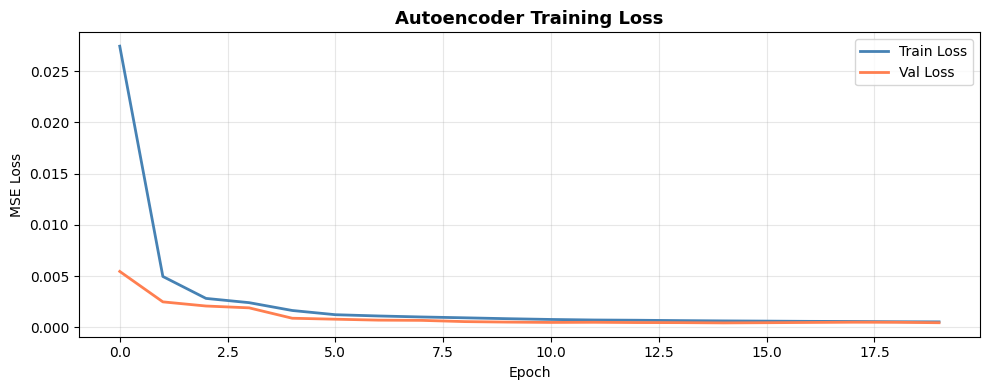

✅ Loss curve saved!


In [5]:
# CELL 5 — Train on NORMAL traffic only
print("Training Autoencoder on normal traffic only...")
print("Takes 5-10 minutes...")
print("=" * 45)

# Use sample of normal traffic for speed
SAMPLE_SIZE = min(200_000, len(X_normal_train))
idx = np.random.choice(
    len(X_normal_train), SAMPLE_SIZE, replace=False)
X_normal_sample = X_normal_train[idx]

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1),
    ModelCheckpoint(
        '/kaggle/working/autoencoder_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1)
]

history = ae.fit(
    X_normal_sample,
    X_normal_sample,    # input = output (reconstruction)
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"   Best val loss: {min(history.history['val_loss']):.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],
         label='Train Loss',
         color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'],
         label='Val Loss',
         color='coral', linewidth=2)
plt.title('Autoencoder Training Loss',
          fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/ae_training_loss.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve saved!")

Computing adaptive MAD threshold...

✅ ADAPTIVE THRESHOLD COMPUTED:
   Median reconstruction error : 0.000086
   MAD value                   : 0.000048
   Threshold (median + 3*MAD)  : 0.000231


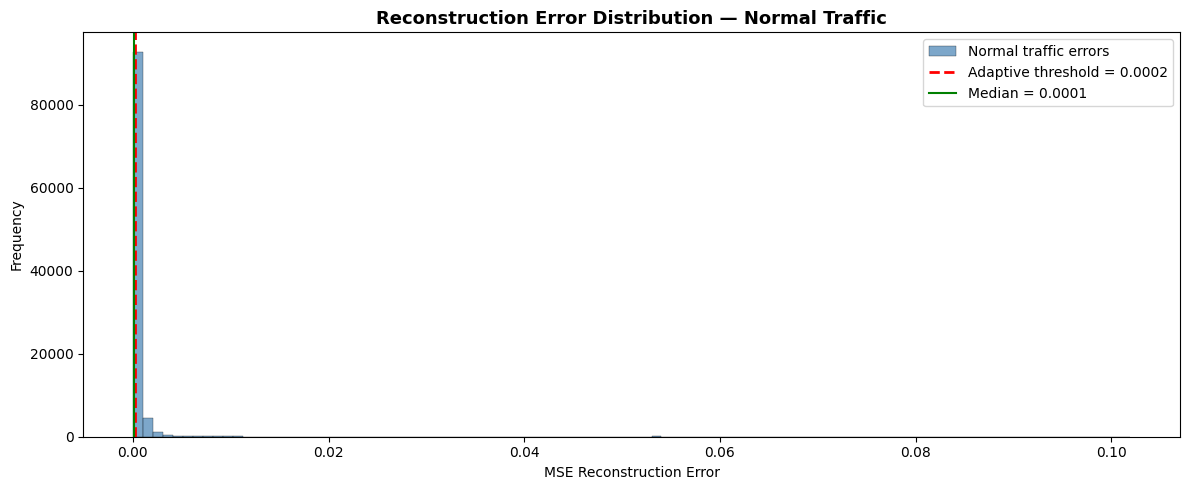

✅ Threshold plot saved!


In [6]:
# CELL 6 — Adaptive threshold using MAD
# This is YOUR NOVELTY — most papers use fixed threshold
# MAD = Median Absolute Deviation — more robust than mean

print("Computing adaptive MAD threshold...")

# Get reconstruction errors on NORMAL traffic
X_normal_full = X_normal_train[:100_000]
recon_normal  = ae.predict(
    X_normal_full, verbose=0)
errors_normal = np.mean(
    np.power(X_normal_full - recon_normal, 2),
    axis=1)

# MAD-based threshold computation
median_err = np.median(errors_normal)
mad        = median_abs_deviation(errors_normal)
threshold  = median_err + 3 * mad

print(f"\n✅ ADAPTIVE THRESHOLD COMPUTED:")
print(f"   Median reconstruction error : {median_err:.6f}")
print(f"   MAD value                   : {mad:.6f}")
print(f"   Threshold (median + 3*MAD)  : {threshold:.6f}")

# Plot reconstruction error distribution
plt.figure(figsize=(12, 5))
plt.hist(errors_normal, bins=100,
         alpha=0.7, color='steelblue',
         label='Normal traffic errors',
         edgecolor='black', linewidth=0.3)
plt.axvline(threshold,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Adaptive threshold = {threshold:.4f}')
plt.axvline(median_err,
            color='green',
            linestyle='-',
            linewidth=1.5,
            label=f'Median = {median_err:.4f}')
plt.title('Reconstruction Error Distribution — Normal Traffic',
          fontsize=13, fontweight='bold')
plt.xlabel('MSE Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/ae_threshold.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Threshold plot saved!")

In [7]:
# CELL 7 — Zero-day detection on full test set
print("Running anomaly detection on test set...")

# Get reconstruction errors for ALL test samples
recon_test  = ae.predict(X_test, verbose=1)
errors_test = np.mean(
    np.power(X_test - recon_test, 2), axis=1)

# Classify using adaptive threshold
# Above threshold = anomaly (potential zero-day)
# Below threshold = normal
ae_preds = (errors_test > threshold).astype(int)

# Compare against true binary labels
# 1 = any attack, 0 = normal
acc_ae = accuracy_score(y_test_binary, ae_preds)
f1_ae  = f1_score(y_test_binary, ae_preds,
                  zero_division=0)
auc    = roc_auc_score(y_test_binary, errors_test)

print(f"\n{'='*50}")
print(f"AUTOENCODER ZERO-DAY DETECTION RESULTS")
print(f"{'='*50}")
print(f"  Accuracy  : {acc_ae:.4f} ({acc_ae*100:.2f}%)")
print(f"  F1-Score  : {f1_ae:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"\nDetection Report:")
print(classification_report(
    y_test_binary, ae_preds,
    target_names=['Normal','Anomaly'],
    zero_division=0))

# False positive and negative rates
fp = ((ae_preds==1) & (y_test_binary==0)).sum()
fn = ((ae_preds==0) & (y_test_binary==1)).sum()
tp = ((ae_preds==1) & (y_test_binary==1)).sum()
tn = ((ae_preds==0) & (y_test_binary==0)).sum()

fpr = fp / (fp + tn) if (fp+tn) > 0 else 0
fnr = fn / (fn + tp) if (fn+tp) > 0 else 0

print(f"  False Positive Rate : {fpr:.4f} ({fpr*100:.2f}%)")
print(f"  False Negative Rate : {fnr:.4f} ({fnr*100:.2f}%)")
print(f"  True Positives      : {tp:,}")
print(f"  True Negatives      : {tn:,}")

Running anomaly detection on test set...
13106/13106 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step

AUTOENCODER ZERO-DAY DETECTION RESULTS
  Accuracy  : 0.7522 (75.22%)
  F1-Score  : 0.6644
  ROC-AUC   : 0.9877

Detection Report:
              precision    recall  f1-score   support

      Normal       1.00      0.67      0.80    316508
     Anomaly       0.50      1.00      0.66    102854

    accuracy                           0.75    419362
   macro avg       0.75      0.84      0.73    419362
weighted avg       0.88      0.75      0.77    419362

  False Positive Rate : 0.3283 (32.83%)
  False Negative Rate : 0.0000 (0.00%)
  True Positives      : 102,852
  True Negatives      : 212,609


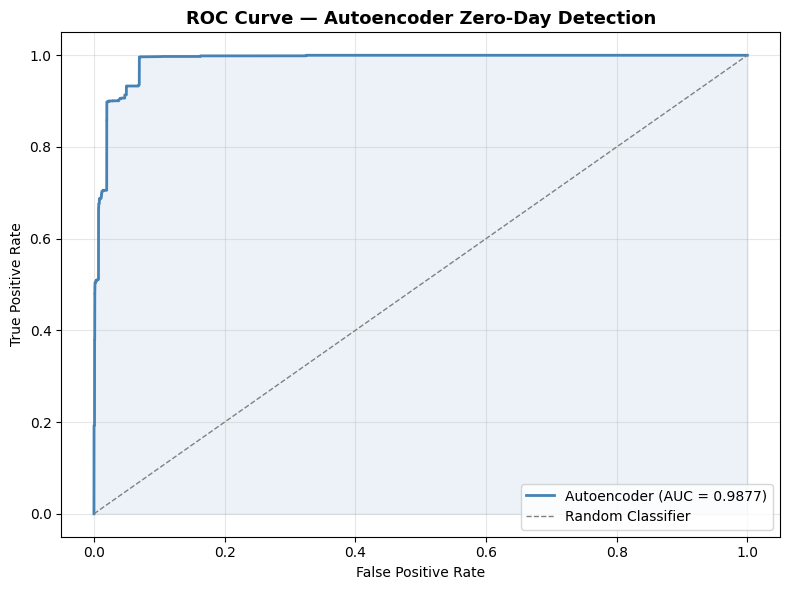

✅ ROC curve saved! AUC = 0.9877


In [8]:
# CELL 8 — ROC Curve
fpr_curve, tpr_curve, _ = roc_curve(
    y_test_binary, errors_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_curve, tpr_curve,
         color='steelblue', linewidth=2,
         label=f'Autoencoder (AUC = {auc:.4f})')
plt.plot([0,1], [0,1],
         color='gray', linestyle='--',
         linewidth=1, label='Random Classifier')
plt.fill_between(fpr_curve, tpr_curve,
                 alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Autoencoder Zero-Day Detection',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/ae_roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ ROC curve saved! AUC = {auc:.4f}")

Plotting error per attack class...


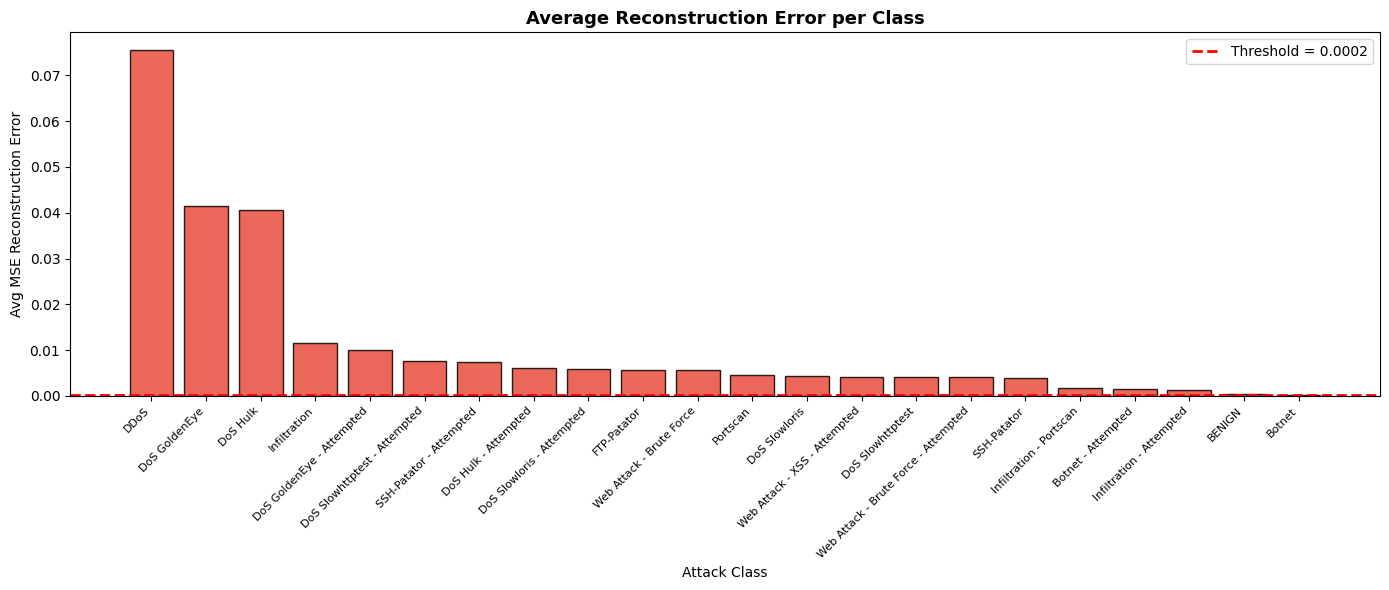

✅ Error per class plot saved!


In [9]:
# CELL 9 — Reconstruction error per attack class
print("Plotting error per attack class...")

# Sample for visualisation speed
sample_idx = np.random.choice(
    len(X_test), 50_000, replace=False)
X_sample      = X_test[sample_idx]
y_sample      = y_test[sample_idx]
errors_sample = errors_test[sample_idx]

# Group errors by class
class_errors = {}
for cls_id, cls_name in enumerate(le.classes_):
    mask = (y_sample == cls_id)
    if mask.sum() > 0:
        class_errors[cls_name] = \
            errors_sample[mask].mean()

# Sort by error value
sorted_errors = dict(sorted(
    class_errors.items(),
    key=lambda x: x[1],
    reverse=True))

# Plot
plt.figure(figsize=(14, 6))
colors = ['#E74C3C' if v > threshold
          else '#2ECC71'
          for v in sorted_errors.values()]
plt.bar(sorted_errors.keys(),
        sorted_errors.values(),
        color=colors, edgecolor='black',
        alpha=0.85)
plt.axhline(threshold, color='red',
            linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.4f}')
plt.title('Average Reconstruction Error per Class',
          fontsize=13, fontweight='bold')
plt.xlabel('Attack Class')
plt.ylabel('Avg MSE Reconstruction Error')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/ae_error_per_class.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Error per class plot saved!")

In [10]:
# CELL 10 — Save everything
results_ae = {
    'model'           : 'Autoencoder',
    'accuracy'        : float(acc_ae),
    'f1_score'        : float(f1_ae),
    'roc_auc'         : float(auc),
    'threshold'       : float(threshold),
    'median_error'    : float(median_err),
    'mad_value'       : float(mad),
    'false_positive_rate': float(fpr),
    'false_negative_rate': float(fnr),
    'true_positives'  : int(tp),
    'true_negatives'  : int(tn),
    'train_samples'   : int(SAMPLE_SIZE),
    'test_samples'    : int(len(X_test))
}

with open('/kaggle/working/autoencoder_results.json',
          'w') as f:
    json.dump(results_ae, f, indent=2)

print("✅ ALL DAY 5 FILES SAVED:")
for fname in sorted(
        os.listdir('/kaggle/working/')):
    if not fname.startswith('.'):
        size = os.path.getsize(
            f'/kaggle/working/{fname}'
            ) // 1024 // 1024
        print(f"  └── {fname:<40s} {size:>4} MB")

print(f"\n🎉 DAY 5 AUTOENCODER COMPLETE!")
print(f"   Accuracy  : {acc_ae*100:.2f}%")
print(f"   F1-Score  : {f1_ae:.4f}")
print(f"   ROC-AUC   : {auc:.4f}")
print(f"   Threshold : {threshold:.6f}")
print(f"\n✅ Ready for Day 6 — Decision Fusion + SHAP!")

✅ ALL DAY 5 FILES SAVED:
  └── ae_error_per_class.png                      0 MB
  └── ae_roc_curve.png                            0 MB
  └── ae_threshold.png                            0 MB
  └── ae_training_loss.png                        0 MB
  └── autoencoder_best.h5                         0 MB
  └── autoencoder_results.json                    0 MB

🎉 DAY 5 AUTOENCODER COMPLETE!
   Accuracy  : 75.22%
   F1-Score  : 0.6644
   ROC-AUC   : 0.9877
   Threshold : 0.000231

✅ Ready for Day 6 — Decision Fusion + SHAP!
